In [1]:
""""
explore THOR trace
"""

'"\nexplore THOR trace\n'

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy
# import pywt

In [3]:
data_root = 'data'
plots_root = 'traces'

mV_per_ADC = 1000. / 4096.
bits = 8
tstep = 12e-9  # Sampling rate in seconds (40 MHz)


In [4]:
all_files = os.listdir(data_root)
all_traces = []
all_trace_names = []

# Extra trace
trace_file_path = 'data/NaI_trace_filtered_220726_045157_buffer_0.txt'
real_trace = np.loadtxt(trace_file_path, skiprows=1)
trace = real_trace[:, 1] / 16  # ADC amplitudes. This trace already in volts... (Jeff). Same number discrete values though
all_traces.append(trace)
all_trace_names.append(trace_file_path)

# Main traces
for file in all_files:
    if not 'xtr' in file:
        continue
        
    read_path = os.path.join(data_root, file)
    all_trace_names.append(read_path)
    print(read_path)
    # data = np.loadtxt(read_path, skiprows=1)
    adc = np.loadtxt(read_path, dtype=np.int32, delimiter=',')
    time = tstep * np.arange(adc.size)
    
    all_traces.append(adc)

    plt.figure()
    plt.plot(time, adc)

    write_file = file.replace('.xtr', '.png')
    write_path = os.path.join(plots_root, write_file)
    plt.savefig(write_path)
    plt.close()

data/UTF-8eRC4188nai_xtr_230803_072838.xtr
data/UTF-8eRC4177nai_xtr_230619_171953.xtr
data/UTF-8eRC4188nai_xtr_220726_044619.xtr
data/UTF-8eRC4188nai_xtr_211218_224158.xtr
data/UTF-8eRC4177nai_xtr_240621_171109_1.xtr
data/UTF-8eRC4177nai_xtr_240621_171109.xtr
data/UTF-8eRC4177nai_xtr_240621_171109_0.xtr
data/UTF-8eRC4188nai_xtr_230801_074114.xtr
data/UTF-8eRC4188nai_xtr_231117_185819.xtr
data/UTF-8eRC4177nai_xtr_240621_164016.xtr
data/UTF-8eRC4188nai_xtr_220725_235815.xtr
data/UTF-8eRC4177nai_xtr_240609_170432.xtr
data/UTF-8eRC4188nai_xtr_230803_072723.xtr
data/UTF-8eRC4177nai_xtr_230622_233119.xtr
data/UTF-8eRC4177nai_xtr_230622_234404.xtr
data/UTF-8eRC4188nai_xtr_220202_154842.xtr
data/UTF-8eRC4177nai_xtr_240712_170619.xtr
data/UTF-8eRC4177nai_xtr_230506_185645.xtr
data/UTF-8eRC4186nai_xtr_230521_182049.xtr
data/UTF-8eRC4177nai_xtr_230428_173042.xtr
data/UTF-8eRC4188nai_xtr_231220_145305.xtr
data/UTF-8eRC4177nai_xtr_240608_235845.xtr
data/UTF-8eRC4177nai_xtr_240608_235519.xtr
data/UT

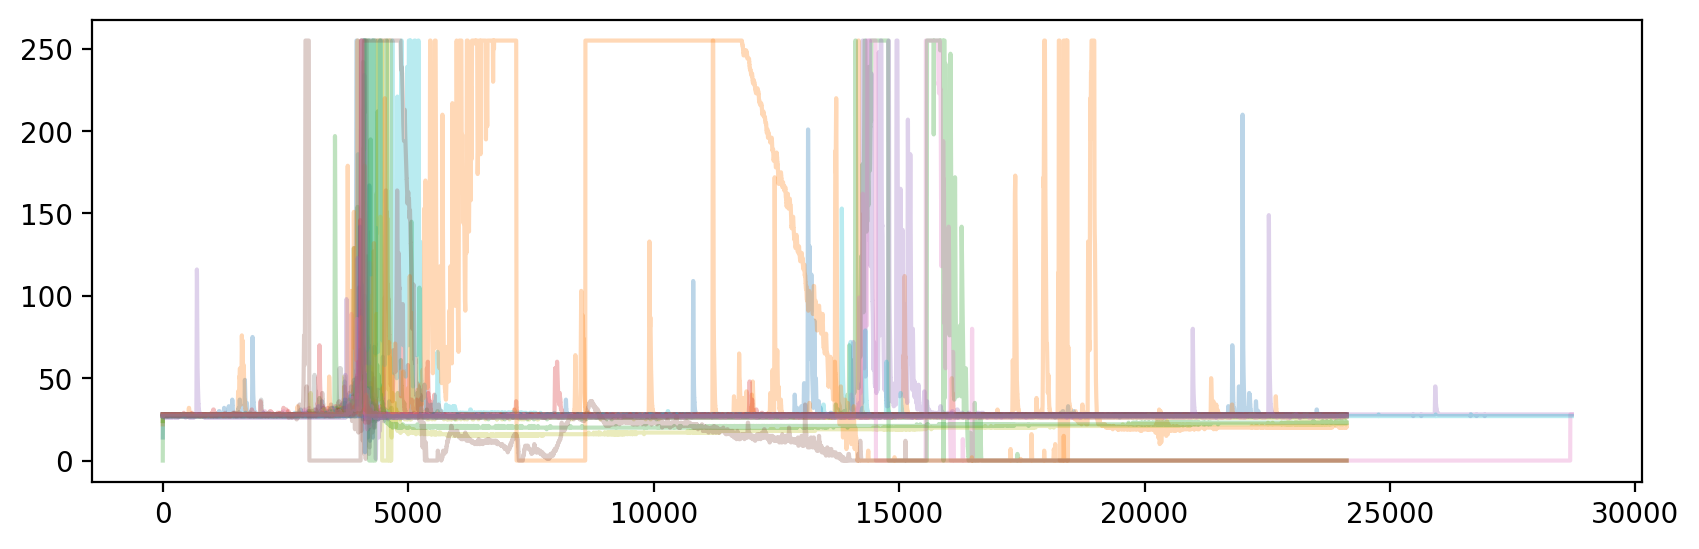

In [5]:
plt.figure(figsize=(10, 3), dpi=200)
for trace, file in zip(all_traces, all_files):
    plt.plot(trace, alpha=.3, label=file)
# plt.legend()


In [6]:
i = 0
print(len(all_traces))

28


1 UTF-8eRC4188nai_xtr_230803_072838.xtr


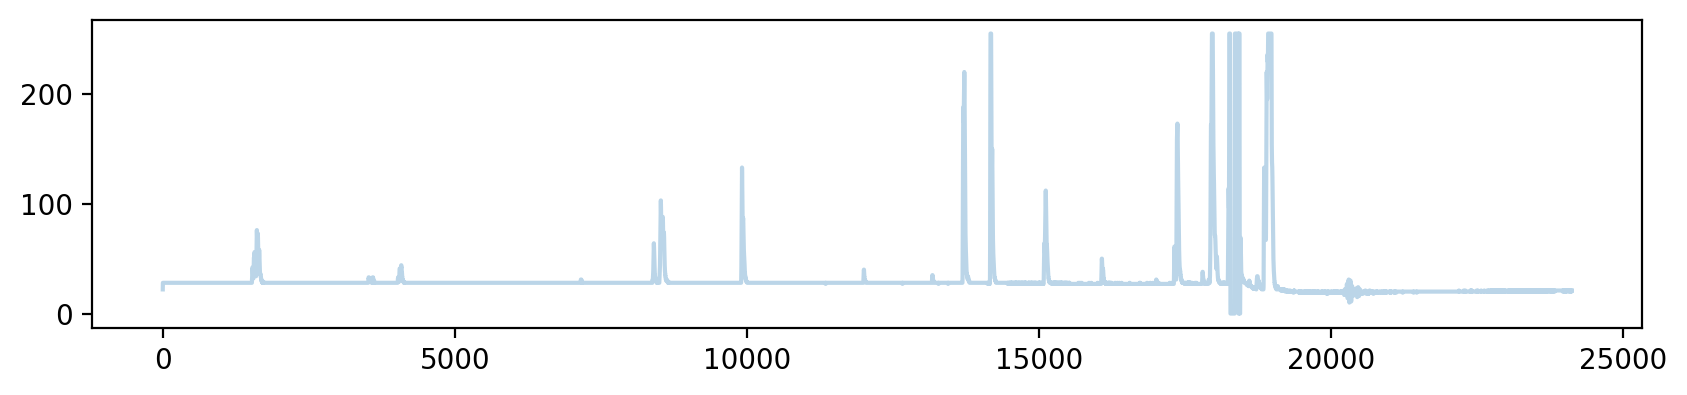

In [7]:
plt.figure(figsize=(10, 2), dpi=200)
i += 1
print(i, all_files[i])
plt.plot(all_traces[i], alpha=.3)

(0.0, 100.0)

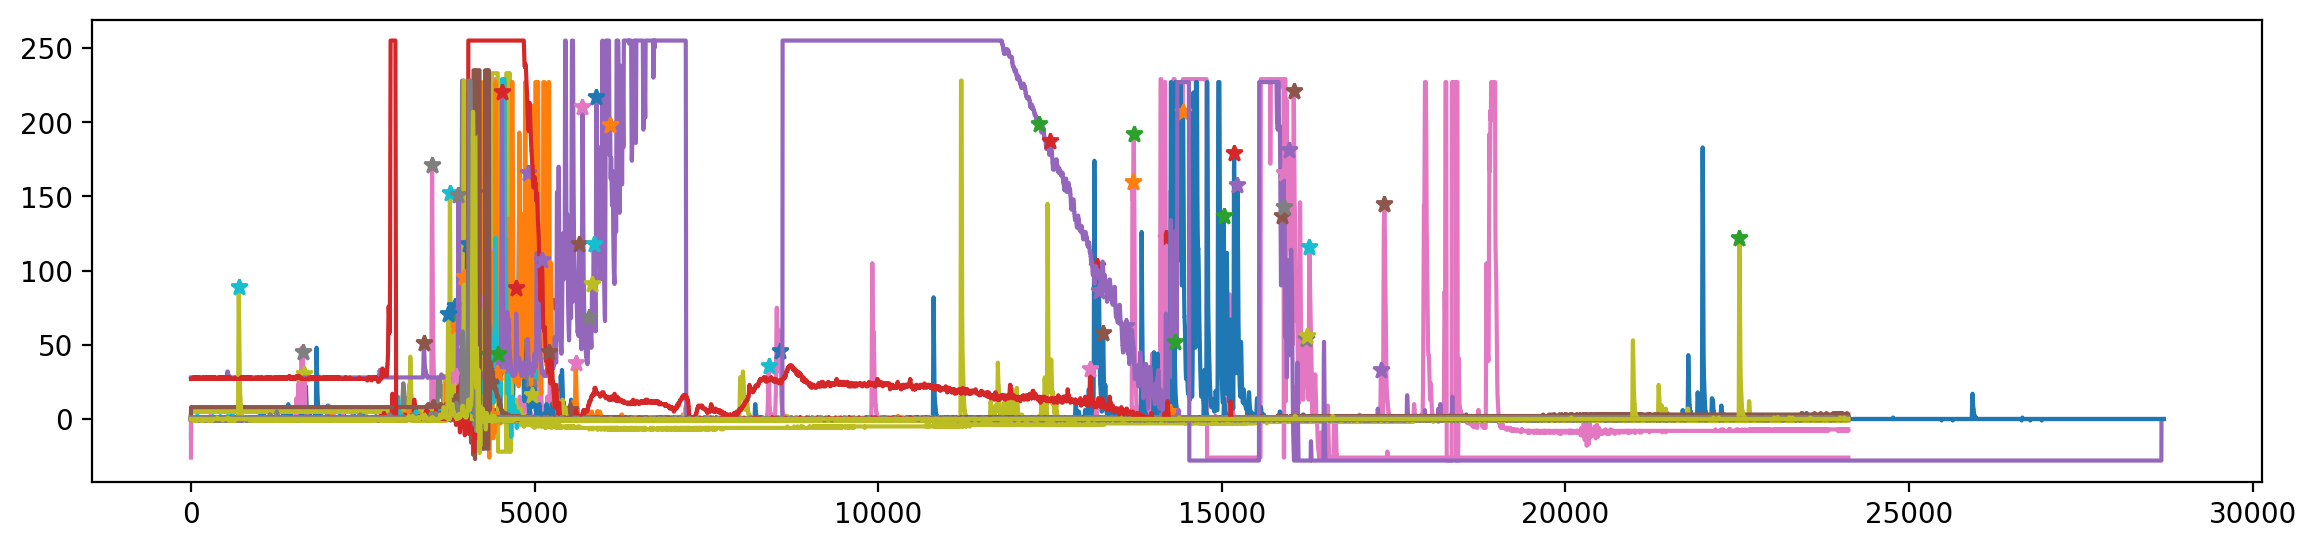

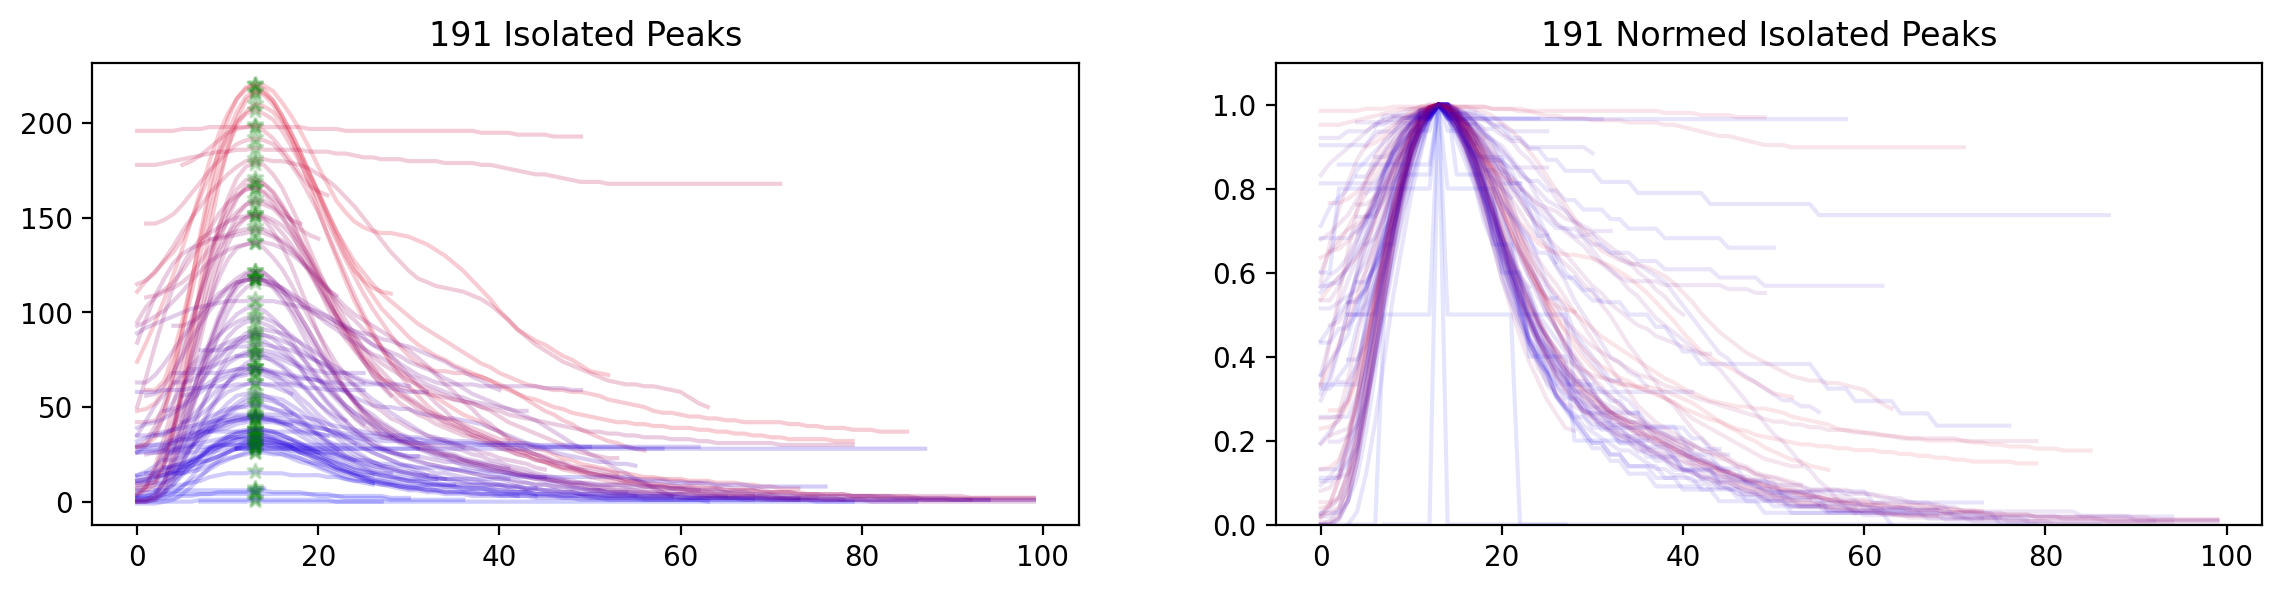

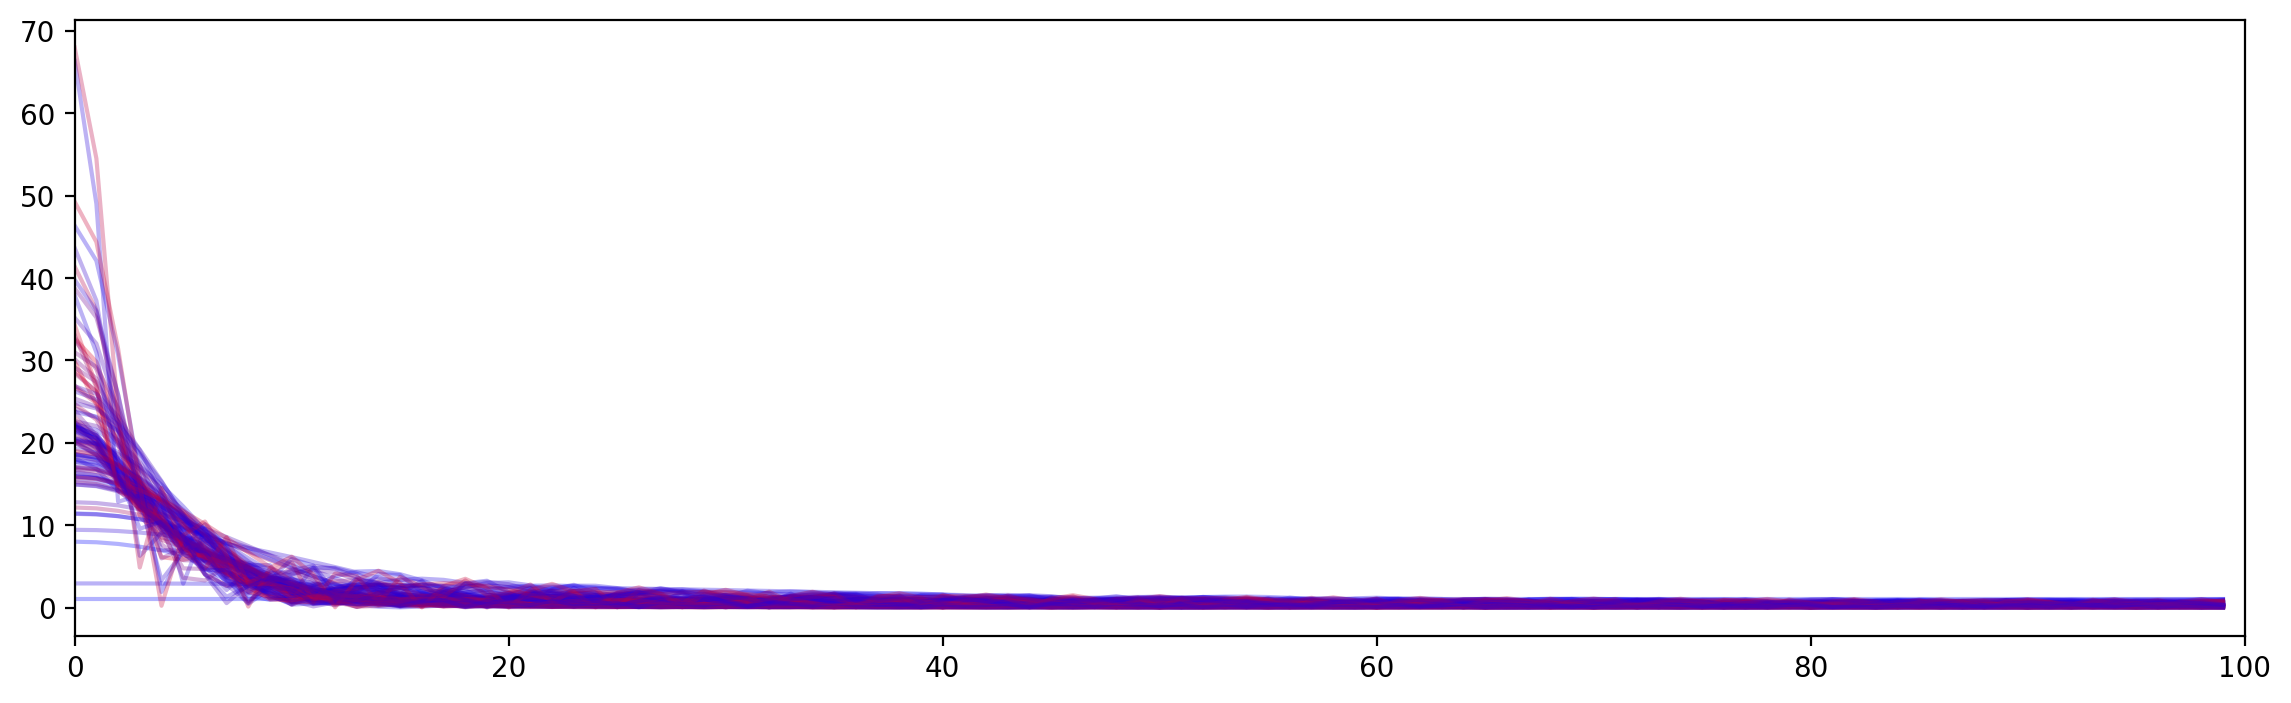

In [8]:
# Locate good trace regions in 8 bit traces by scipy peak finding

dist_to_peak = 13 # TODO might need to change these
kernel_len = 100
trim = True
good_traces = [18,23]
ok_traces = [0,1,2]
all_ok = [0,1,2,18,23]
all = np.arange(len(all_traces))

peaks_and_areas = []

fig1, axes1 = plt.subplots(1, 1, figsize=(14, 3), dpi=200)
fig, axes = plt.subplots(1, 2, figsize=(14, 3), dpi=200)
fig2, axes2 = plt.subplots(1, 1, figsize=(14, 4), dpi=200)

count = 0

for index in all:
    trace = all_traces[index]
    # peaks = scipy.signal.find_peaks(trace, prominence=10)[0]
    sharpened = np.convolve(trace, np.array([-1,100,-1]), mode='same')
    peaks = scipy.signal.find_peaks(sharpened,
                                    distance=3,
                                    # threshold=2 #useless because must be greater than 1, but 2 only gives 2 peaks in entire set
                                    prominence=10,
                                    # plateau_size=[0,2]
                                    )[0]
    
    trace_mode = scipy.stats.mode(trace, keepdims=False)[0]
    zero_baseline = trace - trace_mode
    
    axes1.plot(zero_baseline)
    
    for i, peak in enumerate(peaks):
        event = zero_baseline[peak-dist_to_peak: peak-dist_to_peak+kernel_len]
        event_index = np.arange(event.size)
        if event.size < 1 or zero_baseline[peak] < 1:
            continue
            
        mx = np.max(event)
        if (
            event.size < 50
            or np.sum(event == mx) > 1
            or np.sum(event < -2) > 3
            or np.max(event) < 30
            # or np.where(event/np.max(event) == 1)[0] < dist_to_peak
            # or not np.all(np.diff(event) > 0) # looking for bad cuts that
        ):
            continue  
            
        count += 1
        
        # trim event if values start rising again...
        # if issues, do the above  type filters again to narrow down cause
        if trim:
            dtrace_dt_gt0 = np.where(np.diff(event[dist_to_peak+1:]) > 0)[0] + dist_to_peak+1
            if dtrace_dt_gt0.size > 0:
                cut = dtrace_dt_gt0[0]
                event = event[:cut]
                event_index = event_index[:cut]

            dtrace_dt_lt0 = np.where(np.diff(event[:dist_to_peak-1]) < 0)[0]
            if dtrace_dt_lt0.size > 0:
                cut = dtrace_dt_lt0[-1] + 1 # shift 1 for diff, exclusive upper bound
                event = event[cut:]
                event_index = event_index[cut:]
        
        # center peak if multiple max values...
        if np.sum(np.max(event) == event) > 2:
            new_peak = int(np.mean(np.where(event==np.max(event))[0]))
            delta_index = new_peak - peak
            
            peak = peaks[i] = new_peak
            if delta_index > 0:
                event = event[delta_index:]
                event_index = event_index[delta_index:]
            else:
                event = event[:delta_index]
                event_index = event_index[:delta_index]
        if event.size == 0:
            continue

        axes1.plot(peak, zero_baseline[peak], marker='*', linestyle='')
        
        color = matplotlib.colors.to_hex([zero_baseline[peak]/255,0,(255-zero_baseline[peak])/255])
        axes[0].plot(event_index, event, color=color, alpha=.2)
        axes[0].plot(dist_to_peak, zero_baseline[peak], '*', color='green', alpha=.2)
        axes[1].plot(event_index, event/np.max(event),  color=color, alpha=.1)
        
        padded = np.zeros(kernel_len * 2)
        padded[:event.size] = event/np.max(event)
        fft = scipy.fft.fft(padded)
        fft = np.abs(fft)
        axes2.plot(fft[:fft.size//2], color=color, alpha=.3)

axes[0].set_title('{} Isolated Peaks'.format(count))
axes[1].set_title('{} Normed Isolated Peaks'.format(count))
axes[1].set_ylim(0, 1.1)

# axes2.set_yscale('log')
axes2.set_xlim(0, 100)

# axes1.set_xlim(13000, 15500)

# TODO try enforcing wide "prominnence between minima", with low prominence...

27


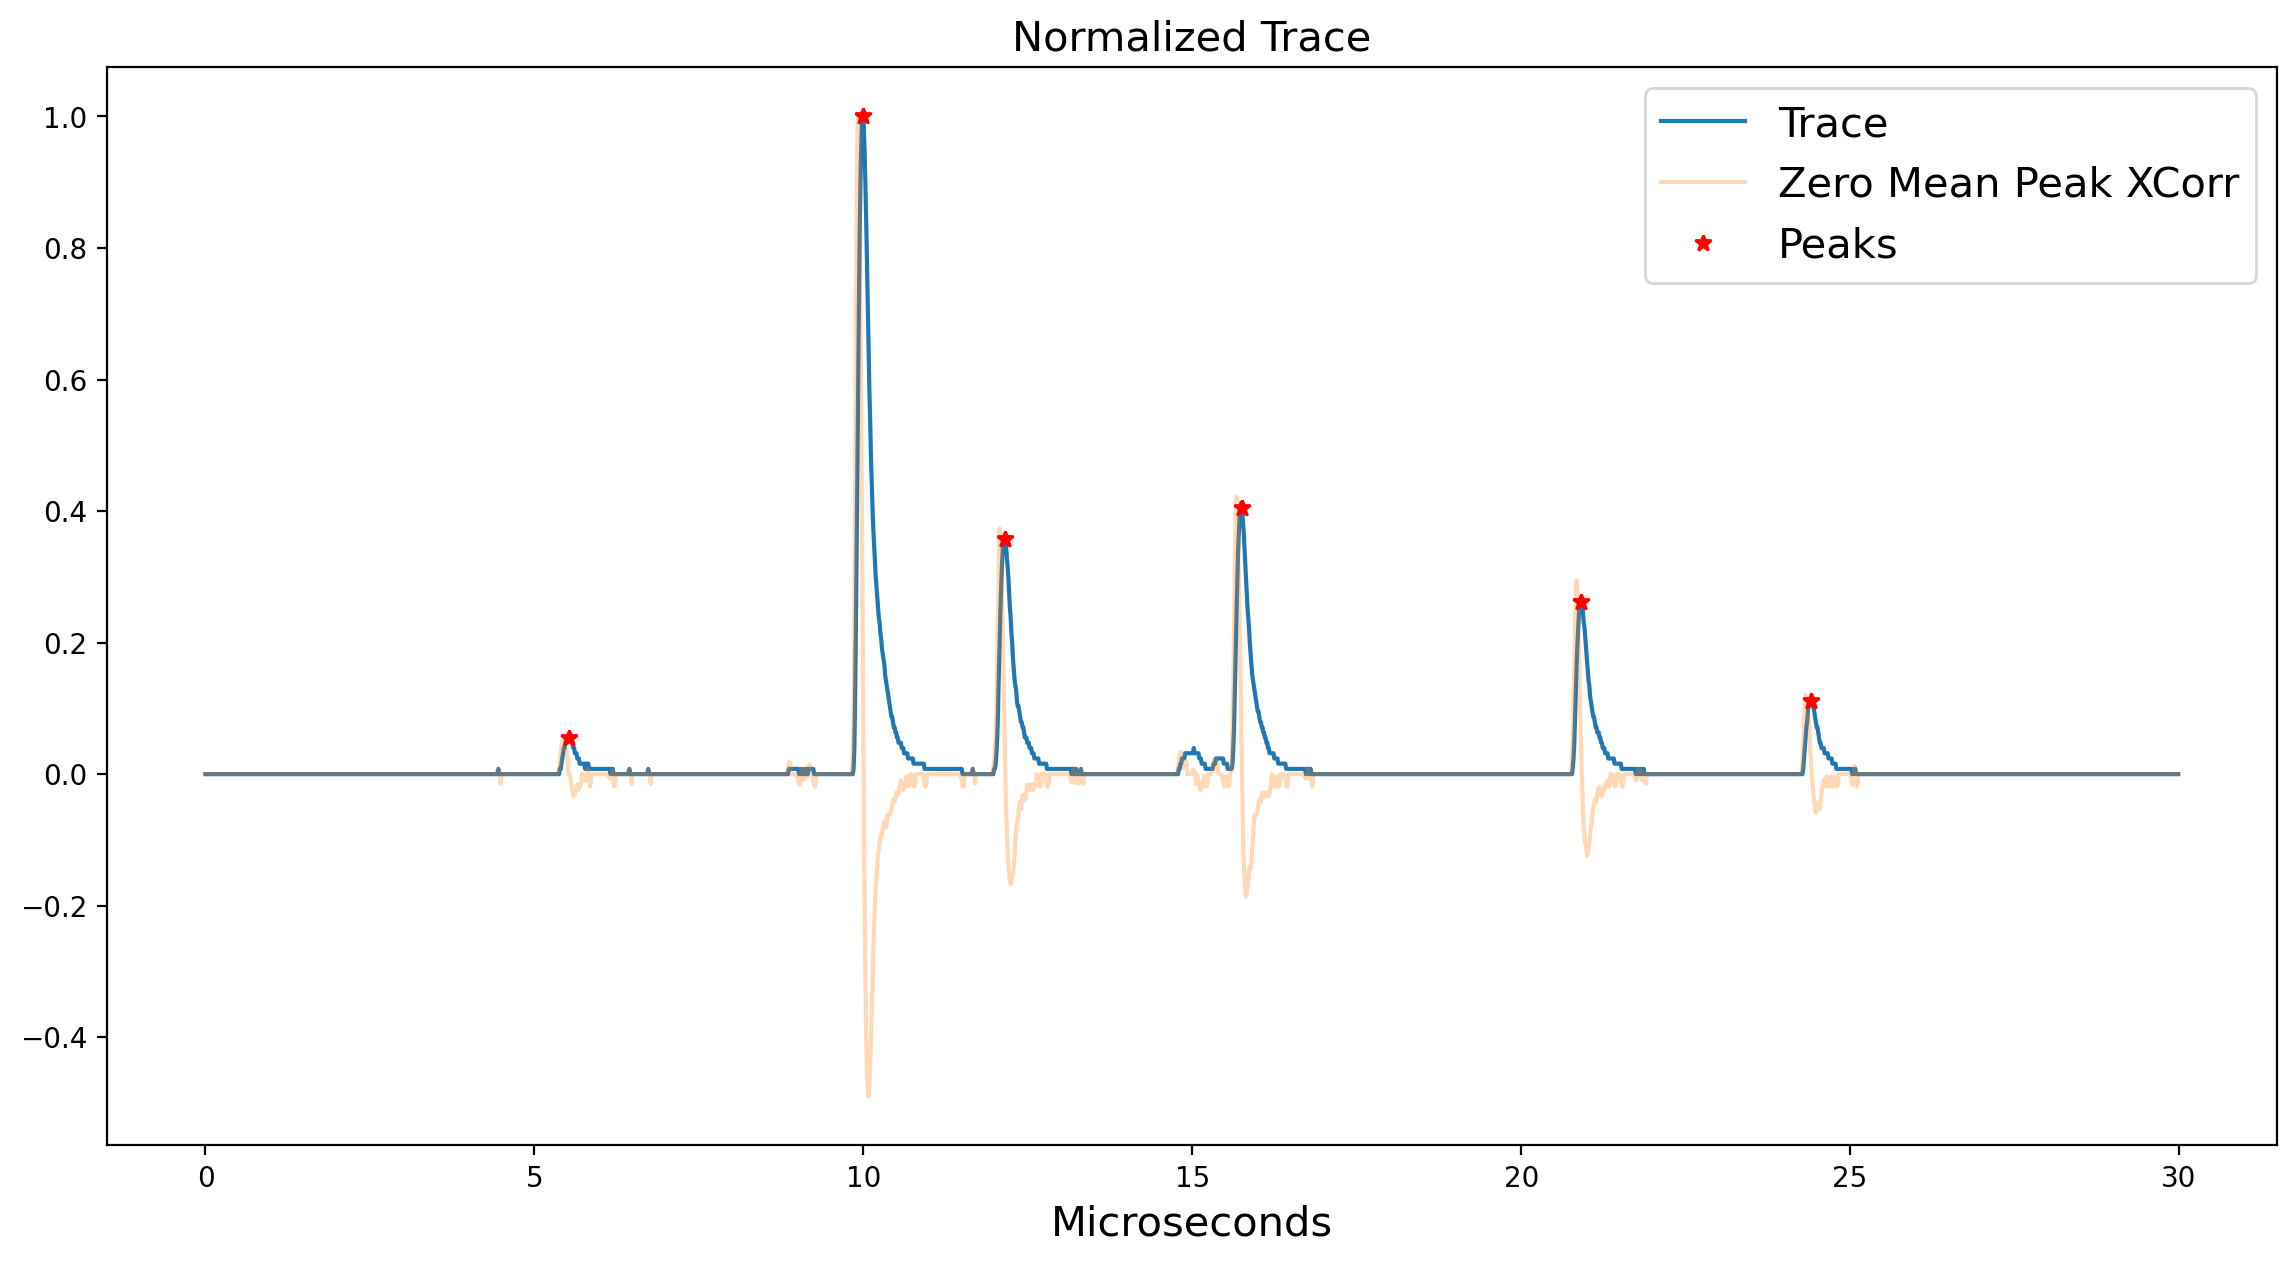

In [9]:
# Demonstrate zero crossings method

trace = all_traces[19]

# lower = 0
# upper = trace.size
lower = 13000
upper = 15500

section = trace[lower:upper]
time = 1E6 * np.arange(section.size) * tstep

print(scipy.stats.mode(section, keepdims=False)[0])
section -= scipy.stats.mode(section, keepdims=False)[0]

fig, axes = plt.subplots(1, 1, figsize=(14, 7), dpi=200)
axes.plot(time, section/np.max(section), label='Trace')
# axes.plot(time, section, label='Trace')

peaks = scipy.signal.find_peaks(section,
                                # distance=3,
                                # threshold=2 #useless because must be greater than 1, but 2 only gives 2 peaks in entire set
                                # prominence=2,
                                # plateau_size=[0,2],
                                )[0]

# mask = np.zeros_like(time)
# mask[peaks] = 1
# mask = mask.astype(bool) & section > 0
# plt.plot(time[mask], section[mask]/np.max(section), linestyle='', marker='*', label='Peaks')
    

from util.Processing import td_nnlsr_deconvolve
from util.DataGen import nai_pulse

_, kernel = nai_pulse(1)
# deconv = td_nnlsr_deconvolve(section, kernel=kernel)
# axes.plot(time, deconv/np.max(deconv), label='Deconv', alpha=.2)

corr = np.correlate(section, kernel, mode='same')
# axes.plot(time, corr/np.max(corr), label='Kernel XCorr', alpha=.3)

kernel_peak = np.argmax(kernel)
peak_width = 3 # < 7
conv_kernel = kernel[kernel_peak-peak_width : kernel_peak + peak_width]
# # corr = np.correlate(section, conv_kernel, mode='same')
# corr = scipy.signal.correlate(section, conv_kernel, mode='same')
# axes.plot(time, corr/np.max(corr), label='Kernel Peak XCorr')

conv_kernel -= np.mean(conv_kernel)
corr = scipy.signal.correlate(section, conv_kernel, mode='same')

axes.plot(time, corr/np.max(corr), label='Zero Mean Peak XCorr', alpha=.3)

zero_crossings = np.diff(np.sign(corr)) != 0 # zero crossings
mask = np.logical_and(zero_crossings.astype(bool), ((section/np.max(section))[:-1]) > .05)

# plt.plot(time[:-1][mask], np.zeros(section.size-1), linestyle='', marker='*', label='Zero Crossings', color='red')
plt.plot(time[:-1][mask], (section[:-1][mask]/np.max(section)), linestyle='', marker='*', label='Peaks', color='red')

axes.set_title('Normalized Trace', fontsize=15)
axes.set_xlabel('Microseconds', fontsize=15)
axes.legend(fontsize=15)

(0.0, 100.0)

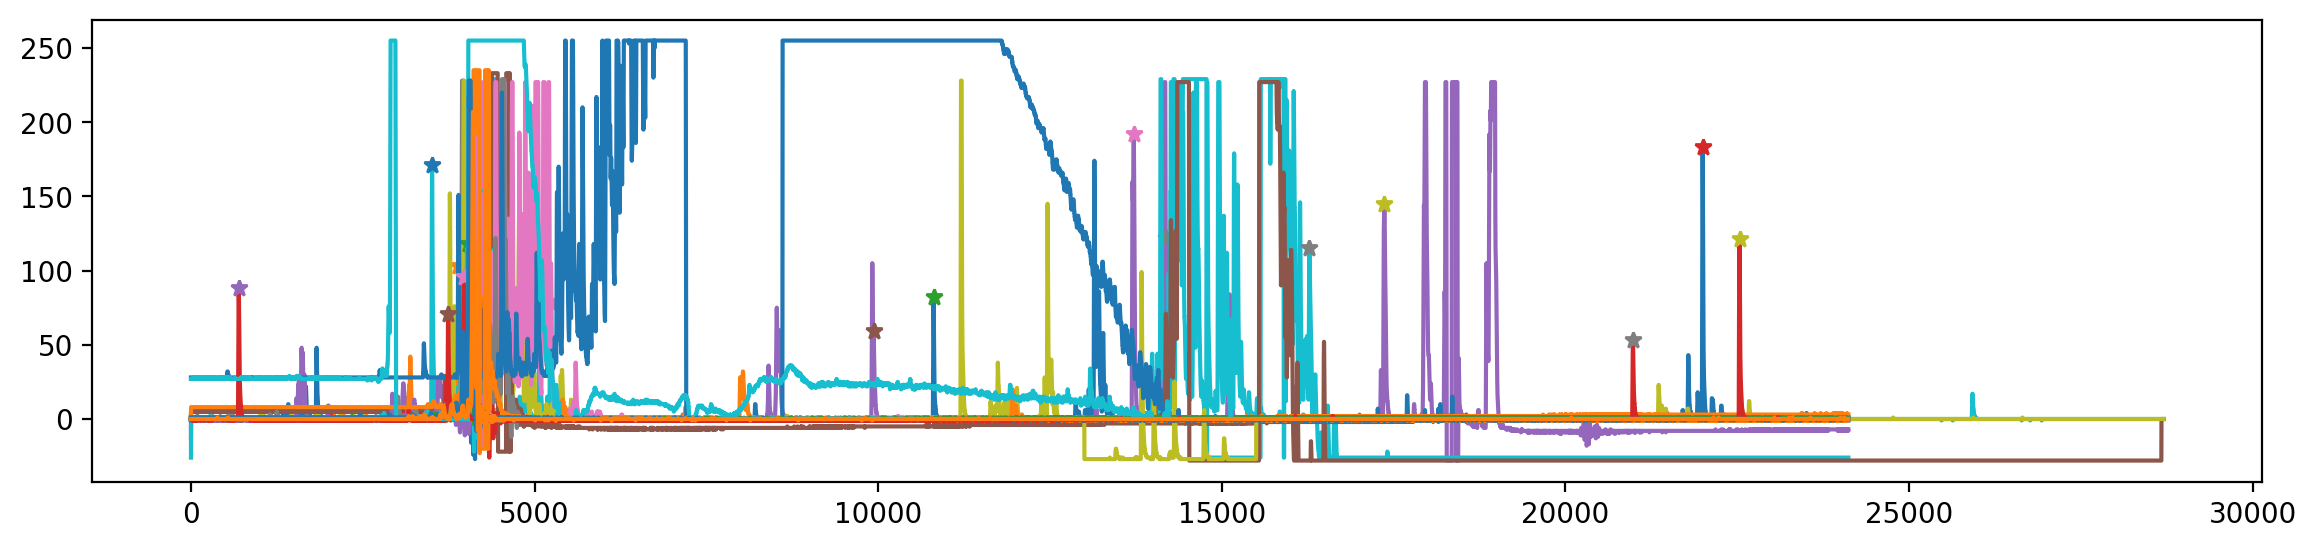

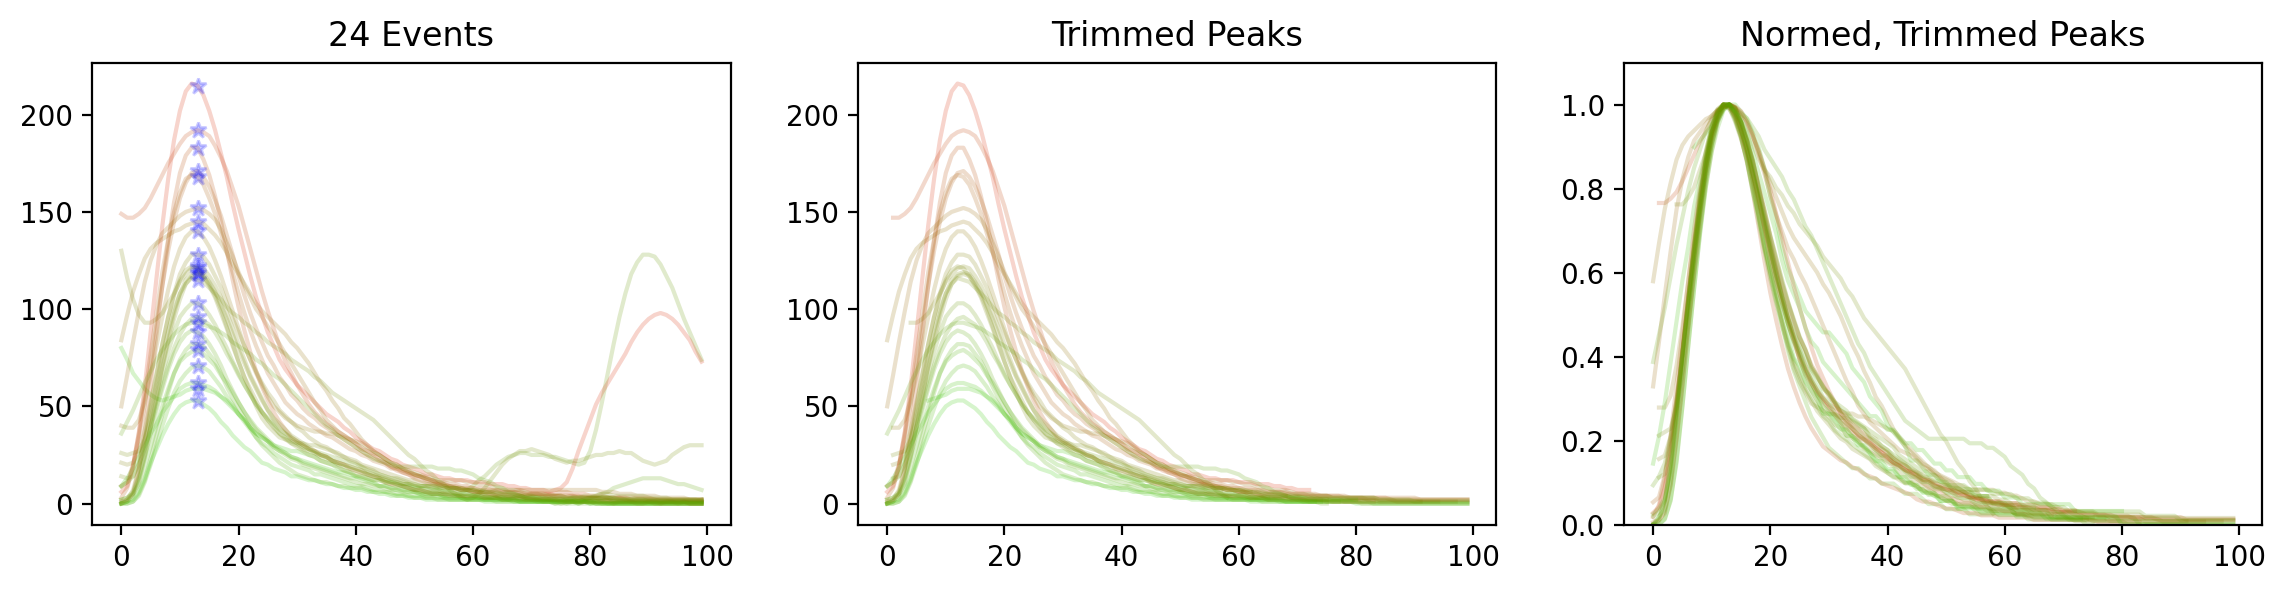

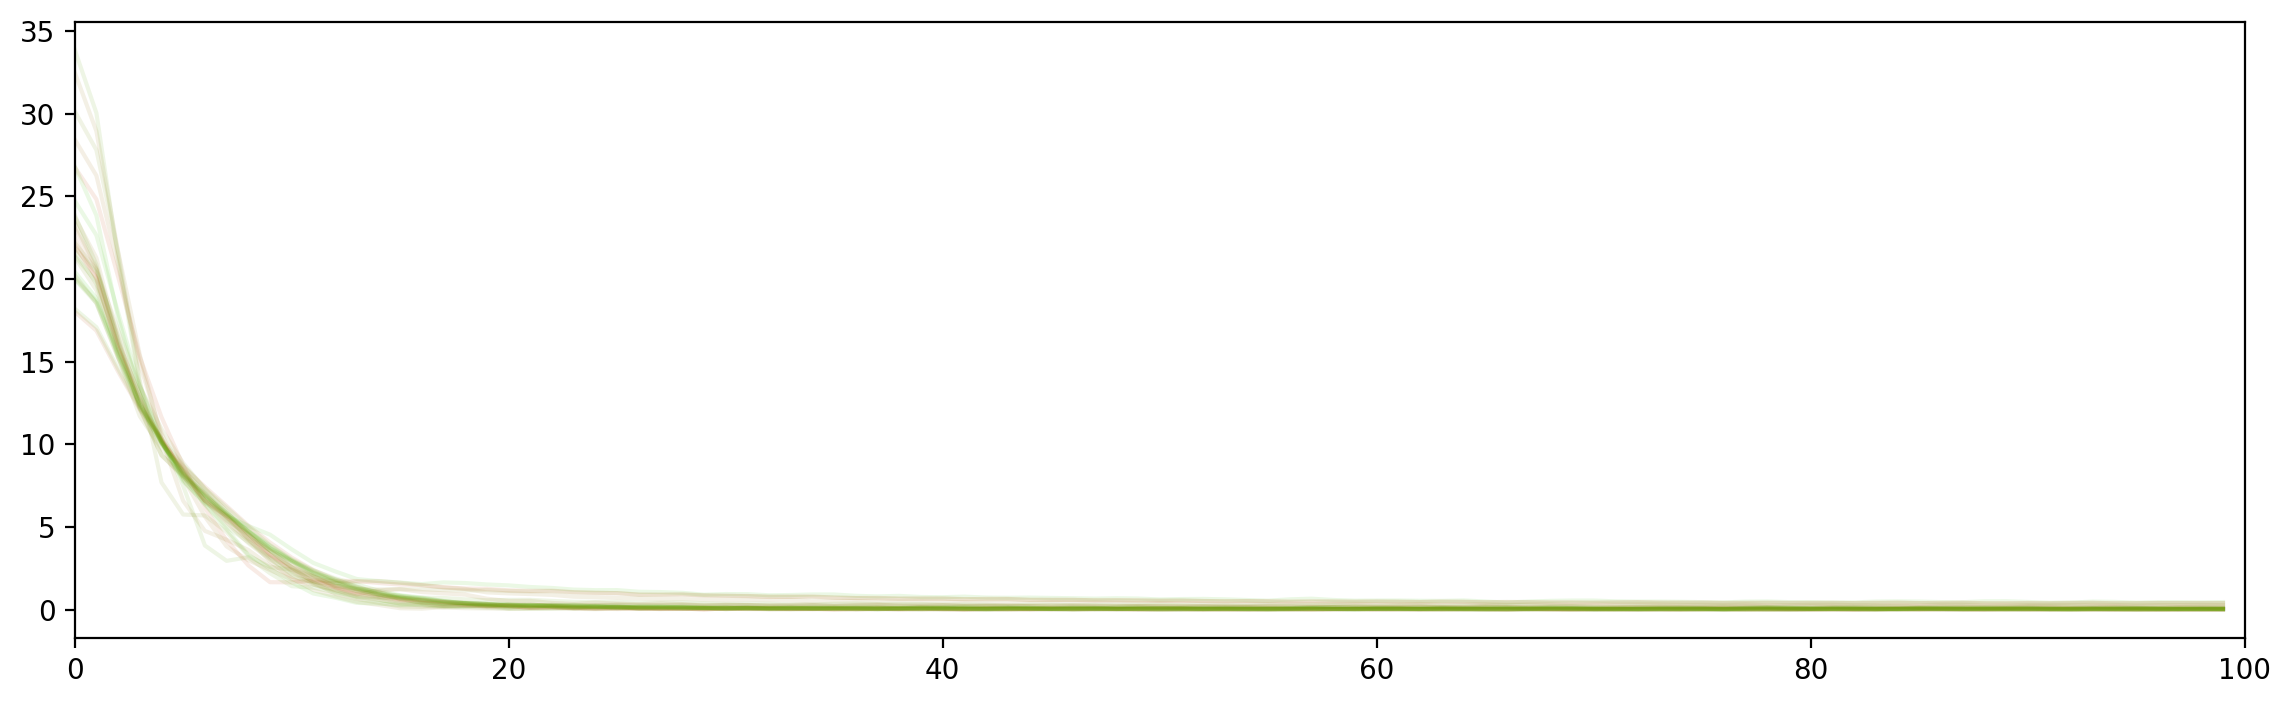

In [10]:
# Locate good trace regions in 8 bit traces by zero crossing method
#
dist_to_peak = 13 # TODO might need to change these
kernel_len = 100
trim = True
good_traces = [19, 24]
ok_traces = [0,1,2,3]
all_ok = [0,1,2,3, 19,24]
all = np.arange(len(all_traces))

peaks_and_areas = []

fig1, axes1 = plt.subplots(1, 1, figsize=(14, 3), dpi=200)
fig, axes = plt.subplots(1, 3, figsize=(14, 3), dpi=200)
fig2, axes2 = plt.subplots(1, 1, figsize=(14, 4), dpi=200)

trimmed_trace_peaks = []
trimmed_trace_names = []

count = 0
n_peaks = 0

for index, trace_name in zip(all, all_trace_names):
    trace = all_traces[index]
    trace_mode = scipy.stats.mode(trace, keepdims=False)[0]
    zero_baseline = trace - trace_mode

    kernel_peak = np.argmax(kernel)
    peak_width = 4 # < 7
    conv_kernel = kernel[kernel_peak-peak_width : kernel_peak + peak_width]
    conv_kernel -= np.mean(conv_kernel)
    
    corr = scipy.signal.correlate(trace, conv_kernel, mode='same')
    zero_crossings = np.diff(np.sign(corr)) != 0 # zero crossings
    thresholded = zero_baseline > 3
    peaks = np.where(zero_crossings & thresholded[:-1])[0]
    
    # print(zero_crossings, zero_crossings.size)
    # print(thresholded, thresholded.size)
    # print(peaks, peaks.size)
    
    n_peaks += peaks.size
    
    axes1.plot(zero_baseline)
    # axes1.plot(corr)
    # axes1.plot(zero_crossings[:-1], corr[zero_crossings], marker='*', color='green', linestyle='')
    # axes1.plot(peaks, corr[peaks], marker='*', color='red', linestyle='')
    
    for peak in peaks:
        event = zero_baseline[peak-dist_to_peak: peak-dist_to_peak+kernel_len]
        event_index = np.arange(event.size)
        
        # trim event if values start rising again...
        # if issues, do the above  type filters again to narrow down cause
        trimmed = event.copy()
        trimmed_index = event_index.copy()
        new_peak = peak
        if trim:
            dtrace_dt_gt0 = np.where(np.diff(trimmed[dist_to_peak+1:]) > 0)[0] + dist_to_peak+1
            if dtrace_dt_gt0.size > 0:
                cut = dtrace_dt_gt0[0]
                trimmed = trimmed[:cut]
                trimmed_index = trimmed_index[:cut]

            dtrace_dt_lt0 = np.where(np.diff(trimmed[:dist_to_peak-1]) < 0)[0]
            if dtrace_dt_lt0.size > 0:
                cut = dtrace_dt_lt0[-1] + 1 # shift 1 for diff, exclusive upper bound
                trimmed = trimmed[cut:]
                trimmed_index = trimmed_index[cut:]
                new_peak = peak + cut
        
        if trimmed.size == 0:
            continue
            
        normed = trimmed/np.max(trimmed)

        if (
            trimmed.size < 50
            or zero_baseline[peak] < 1
            or np.sum(trimmed == np.max(trimmed)) > 5
            or np.sum(trimmed < -2) > 3
            or np.max(trimmed) < 50
            or np.min(normed) > .1
            or np.min(normed[:new_peak]) > .04
            # or np.where(event/np.max(event) == 1)[0] < dist_to_peak
            # or not np.all(np.diff(event) > 0) # looking for bad cuts that
            
            # Good Values for 31 peaks
            # trimmed.size < 50
            # or zero_baseline[peak] < 1
            # or np.sum(trimmed == np.max(trimmed)) > 5
            # or np.sum(trimmed < -2) > 3
            # or np.max(trimmed) < 50
            # or np.min(normed) > .1
            # # or np.where(event/np.max(event) == 1)[0] < dist_to_peak
            # # or not np.all(np.diff(event) > 0) # looking for bad cuts that
        ):
            continue  
            
        count += 1
               
        axes1.plot(peak, zero_baseline[peak], marker='*', linestyle='')
        
        color = matplotlib.colors.to_hex([zero_baseline[peak]/255,(255-zero_baseline[peak])/255, 0])
        axes[0].plot(event_index, event, color=color, alpha=.2)
        axes[0].plot(dist_to_peak, zero_baseline[peak], '*', color='blue', alpha=.2)
        axes[1].plot(trimmed_index, trimmed, color=color, alpha=.2)
        axes[2].plot(trimmed_index, normed,  color=color, alpha=.2)
        
        padded = np.zeros(kernel_len * 2)
        padded[:trimmed.size] = normed
        fft = scipy.fft.fft(padded)
        fft = np.abs(fft)
        axes2.plot(fft[:fft.size//2], color=color, alpha=.1)
        
        trimmed_trace_peaks.append((zero_baseline, peak))
        trimmed_trace_names.append(trace_name)
        
# axes1.set_xlim(4000, 6000)
# axes1.set_xlim(10000, 12000)
# axes1.set_xlim(13250, 15250)

axes[0].set_title('{} Events'.format(count))
axes[1].set_title('Trimmed Peaks')

axes[2].set_title('Normed, Trimmed Peaks')
axes[2].set_ylim(0, 1.1)

# axes2.set_yscale('log')
axes2.set_xlim(0, 100)

Deconv Size: 222
Ratio: 1.0006046080483653
Deconv Size: 186
Ratio: 0.9999999999999989
Deconv Size: 186
Ratio: 1.0089814853075965
Deconv Size: 88
Ratio: 1.0008536987658754
Deconv Size: 110
Ratio: 1.0009790551602593
Deconv Size: 97
Ratio: 1.004180807595393
Deconv Size: 134
Ratio: 1.001760221255122
Deconv Size: 127
Ratio: 1.0001293942321001
Deconv Size: 685
Ratio: 1.0005923311564862
Deconv Size: 685
Ratio: 1.0005923311564862
Deconv Size: 685
Ratio: 1.0005923311564862
Deconv Size: 685
Ratio: 1.0005923311564862
Deconv Size: 186
Ratio: 1.001677235282468
Deconv Size: 120
Ratio: 1.00024537977101
Deconv Size: 476
Ratio: 1.0071876812615121
Deconv Size: 145
Ratio: 1.000225701818342
Deconv Size: 291
Ratio: 1.0019208083186777
Deconv Size: 451
Ratio: 1.001723563844187
Deconv Size: 131
Ratio: 1.0018588134367
Deconv Size: 186
Ratio: 1.0065302917611814
Deconv Size: 186
Ratio: 1.011649889373031
Deconv Size: 100
Ratio: 1.0001387925089738
Deconv Size: 186
Ratio: 1.0026207487600947
Deconv Size: 186
Ratio: 

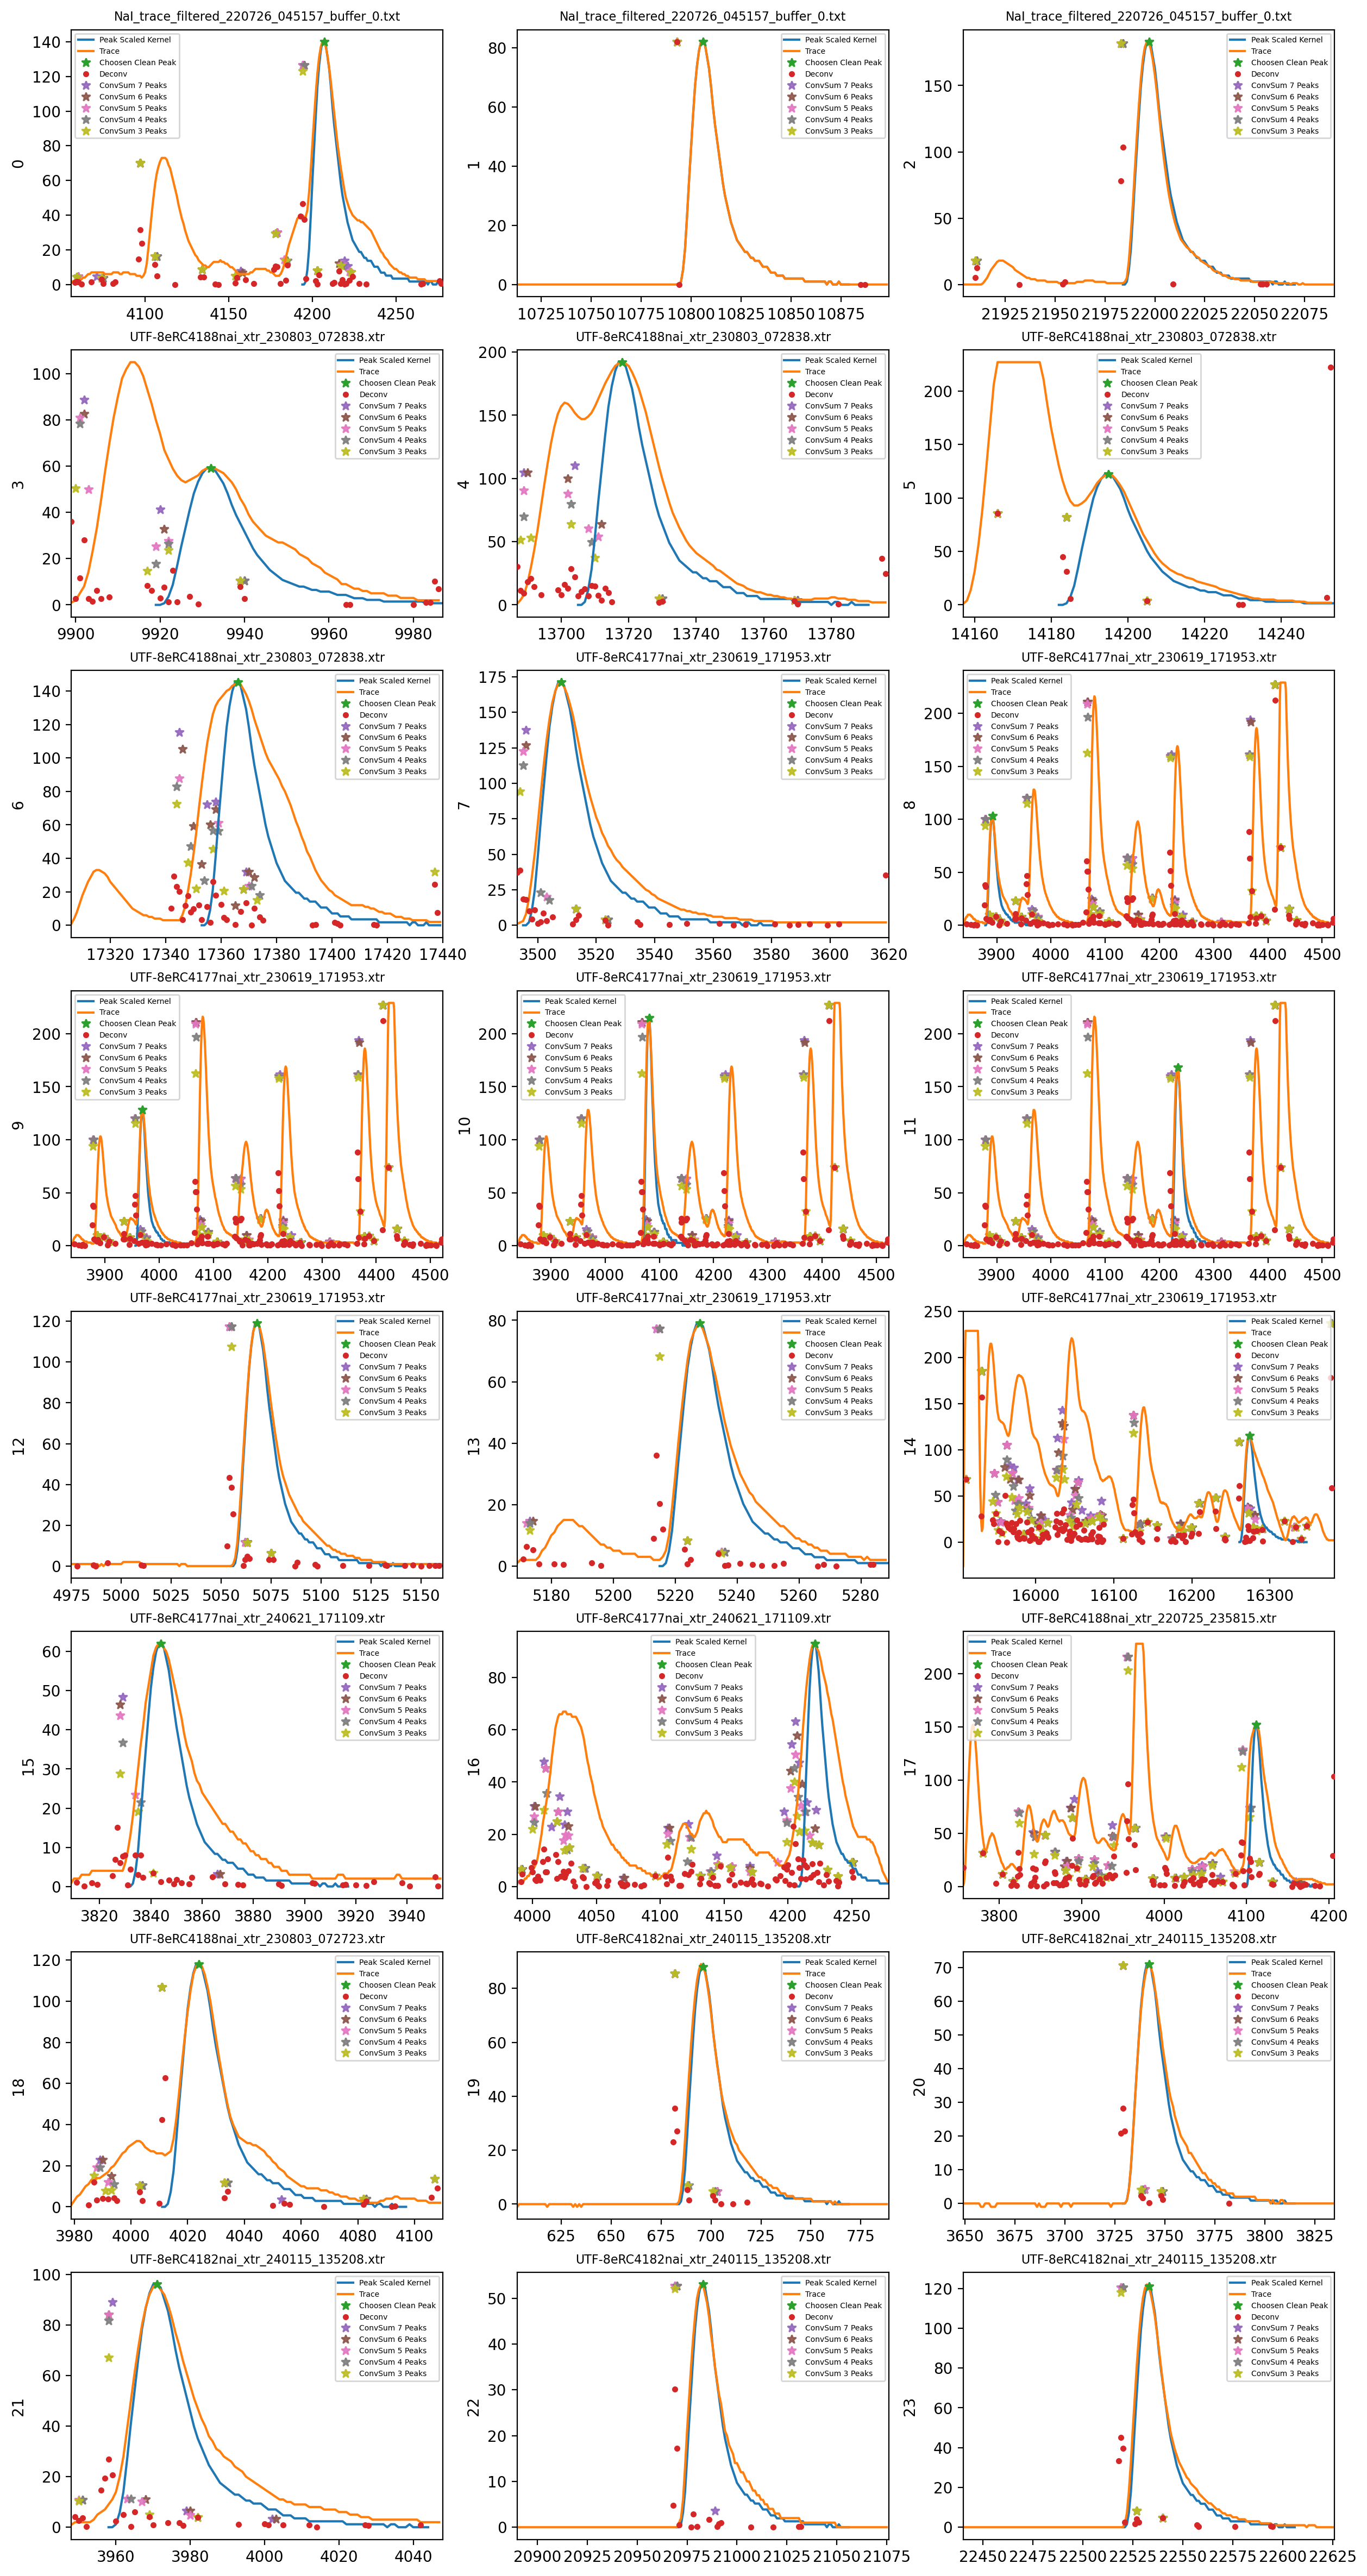

In [11]:
columns = 3
rows = np.ceil(len(trimmed_trace_peaks)/columns).astype(int)

################################################################################################
# Get reference pulse. Note modeled NAI vs real trace pulse could be difference in performance...
# _, kernel = nai_pulse(1)

file_path = '../THOR/data/NaI_trace_pulse_220726_045157_buffer_0.txt'
pulse_data = np.loadtxt(file_path, skiprows=1)  # Skip the header row
pulsetimes = pulse_data[:, 0]  # Time column (in µs)
kernel = pulse_data[:, 1]  # Amplitude column (normalized)
kernel = kernel[83:170]
kernel -= np.min(kernel)
kernel /= np.max(kernel)

################################################################################################

argpeak = np.argmax(kernel)

fig, axes = plt.subplots(rows, columns, figsize=(15, 30), dpi=200)
axes = axes.ravel()

count = 0
for i, (tup, axis, trace_name) in enumerate(zip(trimmed_trace_peaks, axes, trimmed_trace_names)):
    event, peak = tup

    # find good segment around peak
    bound = 1
    left = right = peak
    while event[left] > bound and left > 0:
        left -= 1
    while event[right] > bound and right < event.size:
        right += 1

    if right - left < kernel.size:
        left = peak - kernel.size//2 - 50
        right = peak + kernel.size//2 + 50

     # Dense NNLSR Deconv
    slice_ = event[left : right]
    if slice_.size > 1000:
        left = peak - 500
        right = peak + 500
        slice_ = event[left : right]
    axis.set_xlim(left,right)
    
    print('Deconv Size:', slice_.size)
    index =  np.arange(event.size)[left : right]
    axis.plot(peak - argpeak - 1 + np.arange(kernel.size), event[peak] * kernel, label='Peak Scaled Kernel')
    axis.plot(index, slice_, label='Trace')
    axis.plot(peak, event[peak], marker='*', linestyle='', label='Choosen Clean Peak')
    
    threshold = 0
    deconv = td_nnlsr_deconvolve(slice_, kernel)
    thresh_mask = deconv > threshold
    thresh_deconv = deconv.copy()
    thresh_deconv[thresh_deconv < 0] = 0
    
    ratio = np.sum(deconv) * np.sum(kernel) / np.sum(slice_)
    print('Ratio:', ratio)
    
    axis.plot(index[thresh_mask], thresh_deconv[thresh_mask], marker='.', linestyle='', label='Deconv', zorder=3)

    for n in np.arange(3,8)[::-1].tolist():
        # summed = np.convolve(thresh_deconv, np.ones(n), mode='same')
        # axis.plot(index, summed, alpha=.9,
        #          label='ConvsSum {}'.format(n), zorder=1)

        summed = np.convolve(thresh_deconv, np.ones(n), mode='same')
        peaks,_ = scipy.signal.find_peaks(summed, prominence=3)
        if peaks.size > 0:
            axis.plot(index[peaks], summed[peaks],
                     marker='*', linestyle='', alpha=.9,
                     label='ConvSum {} Peaks'.format(n), zorder=1)
            
    axis.legend(fontsize=5)
    axis.set_ylabel(i)
    axis.set_title(trace_name.split('/')[1], fontsize=8)
    
for i in range(len(trimmed_trace_peaks), axes.size):
    axes[i].set_axis_off()


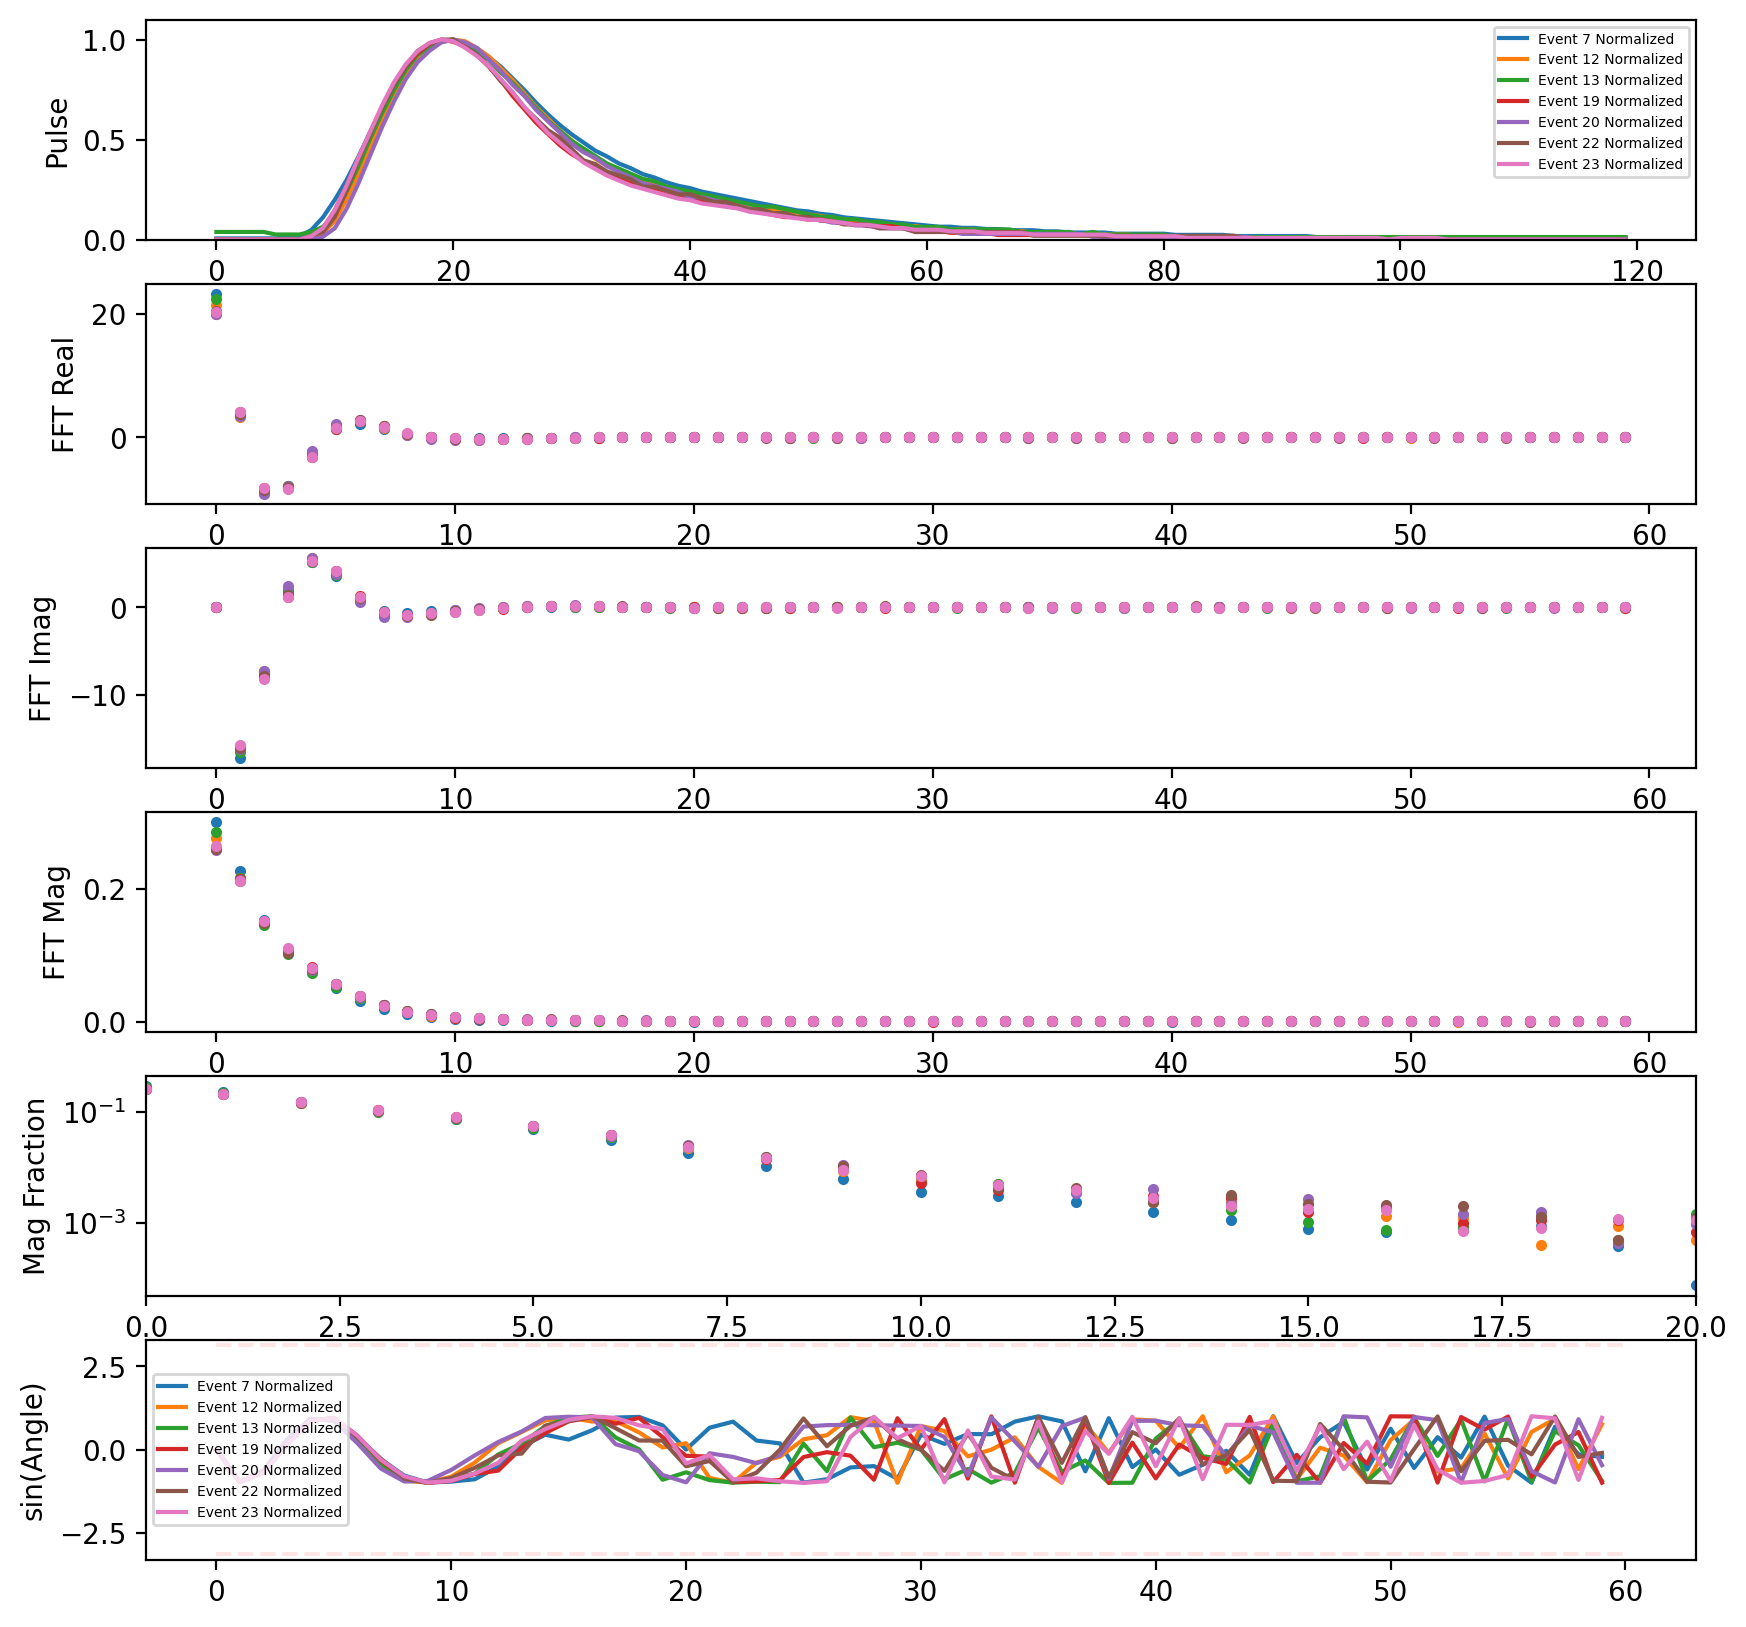

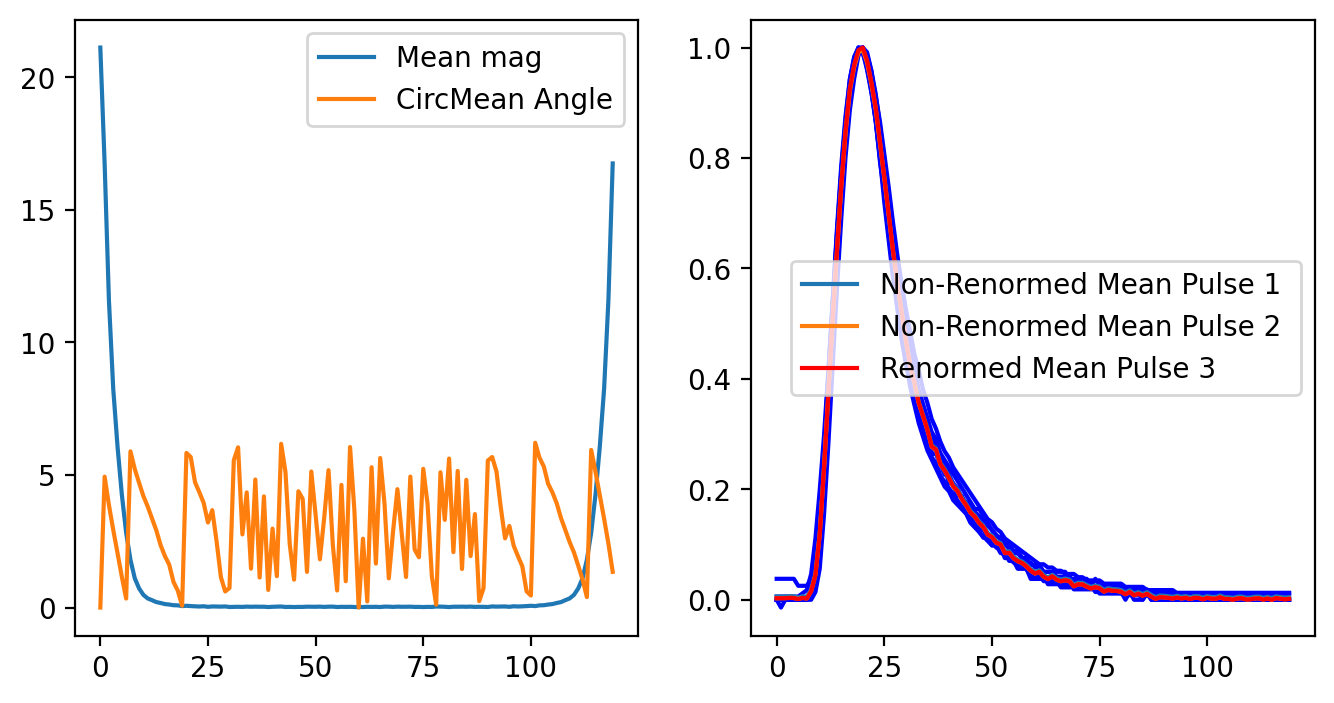

In [12]:
# plot good peaks with
best_peaks = [7,12,13,19,20,22,23] # Exclude 1,2, they are from a different file
# best_peaks = [7,12,13,19,20,21,22,23]
bounds = (-20,100)

spectra = []
    
fig, axes = plt.subplots(6,1, figsize=(10, 10), dpi=200)
fig2, axes2 = plt.subplots(1,2, figsize=(8,4), dpi=200)

for event_pulse in best_peaks:
    event, peak = trimmed_trace_peaks[event_pulse]
    bounded = event[peak+bounds[0] : peak+bounds[1]]
    bounded = bounded / np.max(bounded)
    
    z = scipy.fft.fft(bounded)
    spectra.append(z)
    zabs = np.abs(z)

    axes[0].plot(bounded, label='Event {} Normalized'.format(event_pulse))
    axes2[1].plot(bounded, color='b')
    
    zabs_plot = zabs[:bounded.size//2]
    
    axes[1].plot(np.real(z)[:bounded.size//2], label='Event {} Normalized'.format(event_pulse), marker='.', linestyle='')
    axes[2].plot(np.imag(z)[:bounded.size//2], label='Event {} Normalized'.format(event_pulse), marker='.', linestyle='')
    axes[3].plot(zabs_plot/np.sum(zabs_plot), label='Event {} Normalized'.format(event_pulse), marker='.', linestyle='')
    axes[4].plot(zabs_plot/np.sum(zabs_plot), label='Event {} Normalized'.format(event_pulse), marker='.', linestyle='')
    axes[5].plot(np.sin(np.angle(z))[:bounded.size//2], label='Event {} Normalized'.format(event_pulse))
    # axes[5].plot(np.angle(z), label='Event {} Normalized'.format(event_pulse))

axes[0].set_ylabel('Pulse')
axes[1].set_ylabel('FFT Real')
axes[2].set_ylabel('FFT Imag')
axes[3].set_ylabel('FFT Mag')
axes[4].set_ylabel('Mag Fraction')
axes[5].set_ylabel('sin(Angle)')

axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=5)
axes[5].legend(fontsize=5, loc='center left')

axes[4].set_xlim(0,20)
axes[4].set_yscale('log')

axes[5].set_ylim(-1.05 * np.pi, 1.05 * np.pi)
# axes[5].set_xlim(5,20)
# axes[5].set_xlim(10,15)
# axes[5].set_xlim(0,20)
axes[5].plot([0,60], [-np.pi, -np.pi], 'r--', alpha=.1)
axes[5].plot([0,60], [np.pi, np.pi], 'r--', alpha=.1)

spectra = np.stack(spectra)
mean_mags = np.mean(np.abs(spectra), axis=0)
mean_angles = scipy.stats.circmean(np.angle(spectra), axis=0)
axes2[0].plot(mean_mags,label='Mean mag')
axes2[0].plot(mean_angles,label='CircMean Angle')
axes2[0].legend()

z = mean_mags * np.exp(1j * mean_angles)
un_normed_mean_pulse = scipy.fft.ifft(z)
un_normed_mean_pulse = np.abs(un_normed_mean_pulse)
axes2[1].plot(un_normed_mean_pulse, label='Non-Renormed Mean Pulse 1 ')

un_normed_mean_pulse -= np.min(un_normed_mean_pulse)
axes2[1].plot(un_normed_mean_pulse, label='Non-Renormed Mean Pulse 2')
mean_pulse = un_normed_mean_pulse / np.max(un_normed_mean_pulse)
axes2[1].plot(mean_pulse, label='Renormed Mean Pulse 3', color='r')
axes2[1].legend()
    


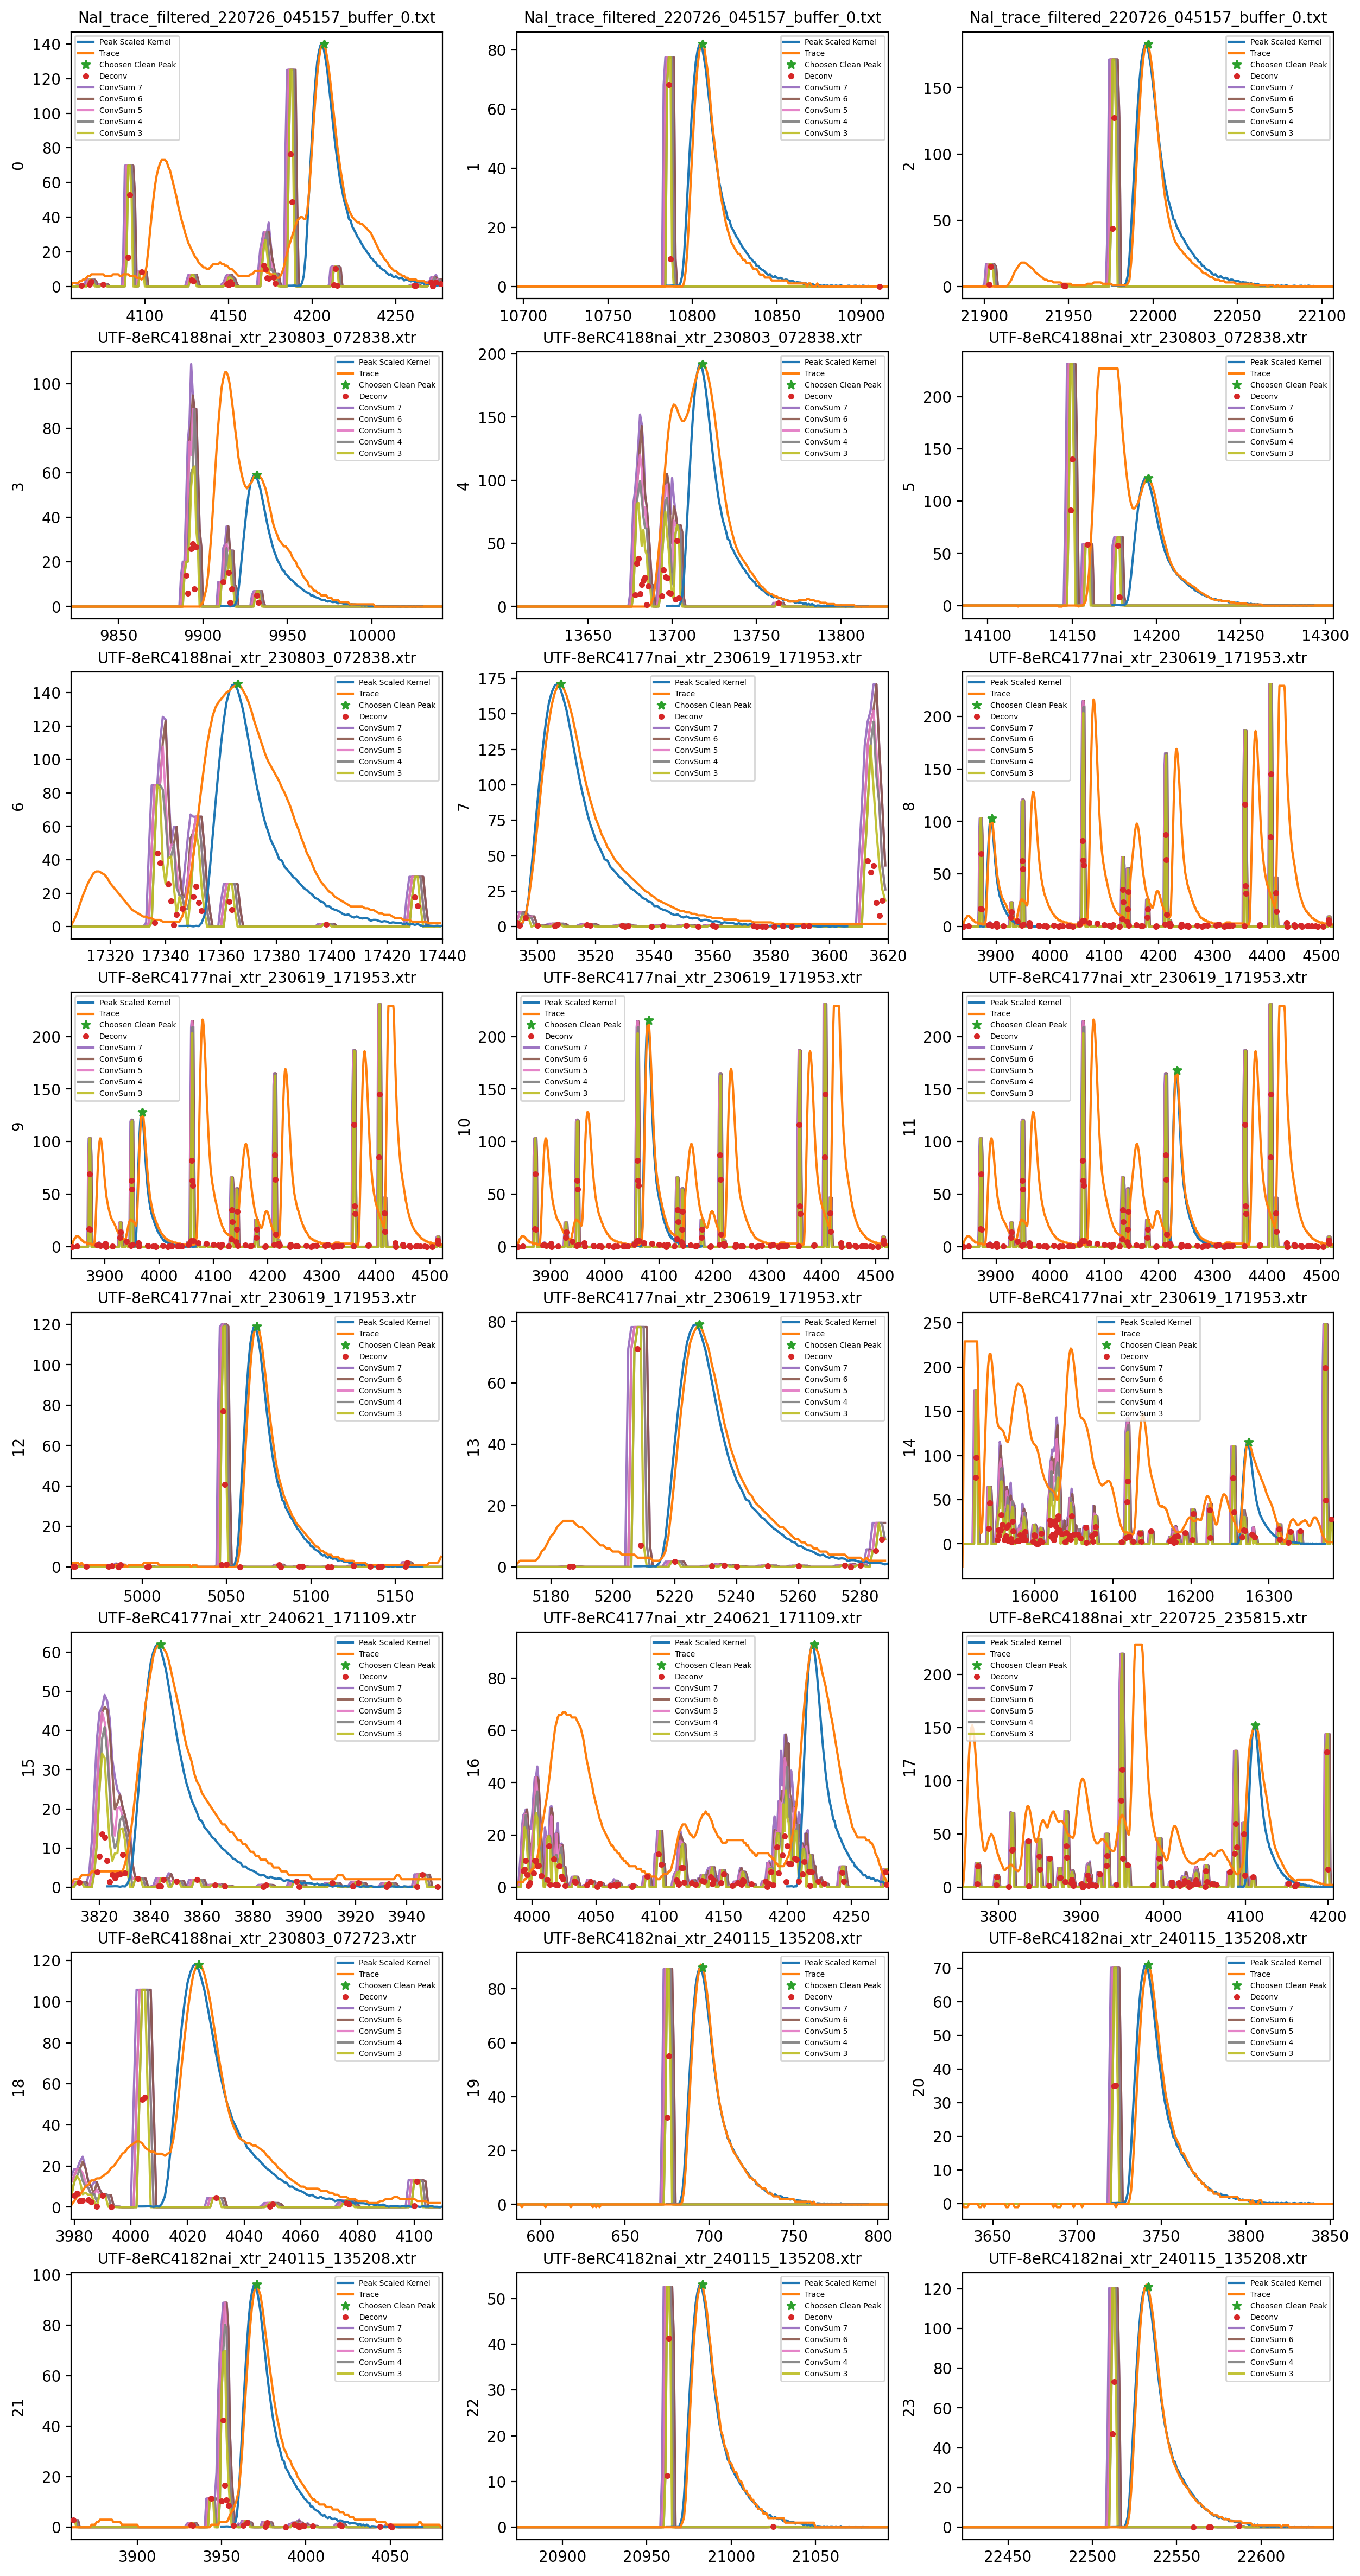

In [13]:
argpeak = np.argmax(mean_pulse)

fig, axes = plt.subplots(rows, columns, figsize=(15, 30), dpi=200)
axes = axes.ravel()

count = 0
for i, (tup, axis, trace_name) in enumerate(zip(trimmed_trace_peaks, axes, trimmed_trace_names)):
    event, peak = tup

    # find good segment around peak
    bound = 1
    left = right = peak
    while event[left] > bound and left > 0:
        left -= 1
    while event[right] > bound and right < event.size:
        right += 1

    if right - left < mean_pulse.size:
        left = peak - mean_pulse.size//2 - 50
        right = peak + mean_pulse.size//2 + 50

     # Dense NNLSR Deconv
    slice_ = event[left : right]
    if slice_.size > 1000:
        left = peak - 500
        right = peak + 500
        slice_ = event[left : right]
    axis.set_xlim(left,right)
    
    index =  np.arange(event.size)[left : right]
    axis.plot(peak - argpeak - 1 + np.arange(mean_pulse.size), event[peak] * mean_pulse, label='Peak Scaled Kernel')
    axis.plot(index, slice_, label='Trace')
    axis.plot(peak, event[peak], marker='*', linestyle='', label='Choosen Clean Peak')
    
    threshold = 0
    deconv = td_nnlsr_deconvolve(slice_, mean_pulse)
    thresh_mask = deconv > threshold
    thresh_deconv = deconv.copy()
    thresh_deconv[thresh_deconv < 0] = 0

    ratio = np.sum(deconv) * np.sum(mean_pulse) / np.sum(slice_)

    axis.plot(index[thresh_mask], thresh_deconv[thresh_mask], marker='.', linestyle='', label='Deconv', zorder=3)
    
    
    #CONVSUM plots
    for n in np.arange(3,8)[::-1].tolist():
        # summed = np.convolve(thresh_deconv, np.ones(n), mode='same')
        # axis.plot(index, summed, alpha=.9,
        #          label='ConvsSum {}'.format(n), zorder=1)

        summed = np.convolve(thresh_deconv, np.ones(n), mode='same')
        axis.plot(index, summed,
                 marker='', linestyle='-', alpha=.9,
                 label='ConvSum {}'.format(n), zorder=1)


        # peaks,_ = scipy.signal.find_peaks(summed, prominence=3)
        # if peaks.size > 0:
        #     axis.plot(index[peaks], summed[peaks],
        #              marker='*', linestyle='', alpha=.9,
        #              label='ConvSum {} Peaks'.format(n), zorder=1)
            
    axis.legend(fontsize=5)
    axis.set_ylabel(i)
    axis.set_title(trace_name.split('/')[1], fontsize='10')
    
for i in range(len(trimmed_trace_peaks), axes.size):
    axes[i].set_axis_off()
    
# Note: when kernel is "larger" than trace for local event, paritcularly at the right hand midsection, deconv is clearner than when 
# it is smaller. Compare "worse clean" deconvs from first to "worse clean" deconvs from the second set. This is likely due to the properties of NNLSR not 
# being able to compensate for an overestimate, not an underestimate. Might indicate we could improve performance for single events by slightly biasing 
# kernel magnitude up... but how does that affect area under the kernel?


In [14]:
# no_event_traces =[]
# event_traces = []
# 
# for trace in all_traces:
#     fig, axes = plt.subplots(1,1, figsize=(8,2), dpi=200)
#     index = np.arange(trace.size)
#     axes.plot(index, trace, '-')
#     
#     def moving_median(input, size):
#         N_conv = int(((input.size - size + 2 * 0) / 1)+1) # discrete convolution output size formula
#         local_median_index = np.tile(np.arange(size), reps=(N_conv, 1))
#         local_median_index = local_median_index + np.arange(N_conv)[:, None]
#         median_segments = input[local_median_index.ravel()].reshape(local_median_index.shape)
#         
#         medians = np.median(median_segments, axis=1) 
#         median_index = np.arange(medians.size) + (trace.size-N_conv)//2
#         
#         return medians, median_index
# 
#     medians, median_index = moving_median(trace, 50)
#     corrected_medians1 = np.median(medians) * np.ones_like(trace)
#     corrected_medians1[median_index] = medians
#     # axes.plot(median_index, medians, color='orange', linestyle='', marker='.', markersize=1)
#     axes.plot(corrected_medians1, color='orange', linestyle='', marker='.', markersize=1)
#     
#     medians, median_index = moving_median(trace, 2000)
#     corrected_medians2 = np.median(medians) * np.ones_like(trace)
#     corrected_medians2[median_index] = medians
#     # axes.plot(median_index, medians, color='green', linestyle='', marker='.', markersize=1)
#     axes.plot(corrected_medians2, color='green', linestyle='', marker='.', markersize=1)
#     
#     valid = corrected_medians1 == corrected_medians2
#     valid = np.logical_and(valid, trace == corrected_medians2)
#     valid_index = index[valid]
#     good_diff = np.where(np.diff(valid_index) > 2)
#     good_index = valid_index[good_diff]
#     axes.plot(good_index, np.zeros_like(good_index), color='red', linestyle='', marker='.', markersize=1)
#     
#     # axes.set_xlim(0,5000)
#     
#     # median_diff = np.diff(medians)
#     # valid = np.where(median_diff < 1)[0]
#     # axes.plot(median_index[valid], medians[valid], 'r*')
#     
#     
#     # vals, counts = np.unique(trace, return_counts=True)
#     # mode = vals[np.argsort(counts)[-1]]
#     # 
#     # bound = 10
#     # desired_pad = 1 * kernel.size
#     # 
#     # valid = np.logical_and(mode - bound < trace, trace < mode + bound)
#     # axes.plot(index[valid], trace[valid], '*')
#     # 
#     # invalid = np.logical_not(valid)
#     # index = np.arange(trace.size)
#     # 
#     # invalid_index = index[invalid]
#     # invalid_spacing = np.diff(invalid_index)
#     
#     # optimal = invalid_spacing > desired_pad
#     # a = invalid_index[:-1][optimal]
#     # segment_bounds = np.concatenate((a+desired_pad//2, a + invalid_spacing[optimal]-desired_pad//2))
#     # segment_bounds = np.sort(segment_bounds)
#     # 
#     # axes.plot(segment_bounds, mode * np.ones_like(segment_bounds), '*')
#     # axes.plot(0, mode, 'r*') 
#     
#     # axes.set_xlim(3500, 5000)
#     # axes.set_xlim(12500, 13500)
#     
#     # break


In [15]:
# # Seperate segments
# no_event_traces =[]
# event_traces = []
# for i in range(segment_bounds.size-1):
#     sub_trace = trace[segment_bounds[i]:segment_bounds[i+1]]
# 
#     if np.any(np.logical_or(sub_trace < -bound, bound < sub_trace)):
#         event_traces.append((sub_trace, (segment_bounds[i], segment_bounds[i+1])))
#     else:
#         no_event_traces.append((sub_trace))
# 
# for bounds in event_traces:
#     plt.plot(bounds[1], np.zeros(2), marker='*', linestyle='')
# 
# filename = 'Trace.png'
# path = os.path.join(figures, filename)
# plt.savefig(path)
# plt.close()